c:\Users\vulam\miniconda3\envs\mmrec\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Min: 0.17016391
Max: 0.4676285
Mean: 0.27620023
Median: 0.2778891324996948
Selected edges: 35565
Removed edges: 82986


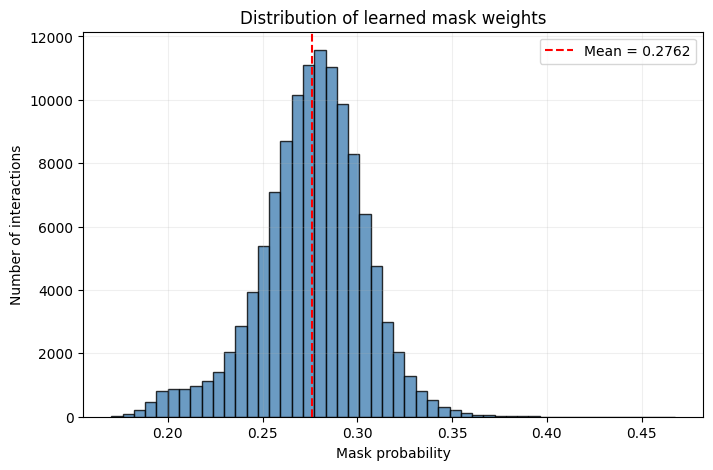

In [1]:
import torch
import matplotlib.pyplot as plt

file_path = r"C:\study\Master_papers\code\multimodal_RS\PGL\src\saved\PGL_MASKED-baby-seed999-Sep-01-2026-04-06-39-analysis.pt"

data = torch.load(file_path, map_location="cpu")

mask_data = data["masks"]["masked_branch"]
weights = mask_data["probabilities"].numpy()
selected = mask_data["selected_at_keep_ratio"].numpy()

print("Min:", weights.min())
print("Max:", weights.max())
print("Mean:", weights.mean())
print("Median:", float(torch.tensor(weights).median()))
print("Selected edges:", selected.sum())
print("Removed edges:", (~selected).sum())

plt.figure(figsize=(8, 5))

plt.hist(
    weights,
    bins=50,
    color="steelblue",
    edgecolor="black",
    alpha=0.8
)

plt.axvline(
    weights.mean(),
    color="red",
    linestyle="--",
    label=f"Mean = {weights.mean():.4f}"
)

plt.xlabel("Mask probability")
plt.ylabel("Number of interactions")
plt.title("Distribution of learned mask weights")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

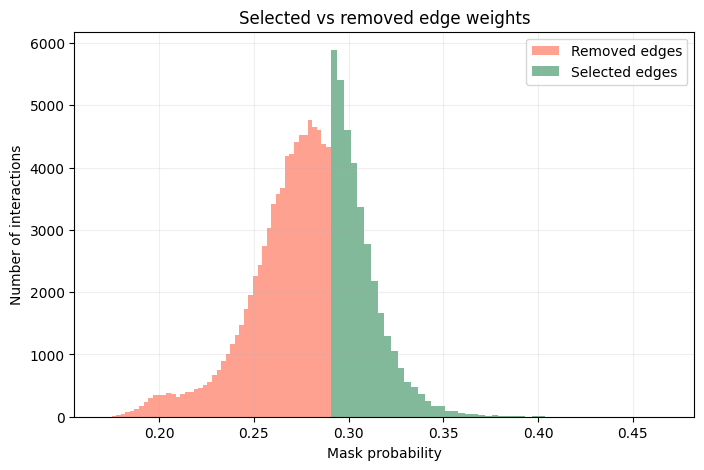

In [2]:
selected_weights = weights[selected]
removed_weights = weights[~selected]

plt.figure(figsize=(8, 5))

plt.hist(
    removed_weights,
    bins=50,
    alpha=0.6,
    label="Removed edges",
    color="tomato"
)

plt.hist(
    selected_weights,
    bins=50,
    alpha=0.6,
    label="Selected edges",
    color="seagreen"
)

plt.xlabel("Mask probability")
plt.ylabel("Number of interactions")
plt.title("Selected vs removed edge weights")
plt.legend()
plt.grid(alpha=0.2)
plt.show()